# 01 · Standard Attention

> 本 Notebook 用于理解 Scaled Dot-Product Attention 的数学原理、朴素实现与性能特征，是后续 FlashAttention 优化的基准。

**目录**
1. [背景与动机](#1-背景与动机)
2. [数学定义](#2-数学定义)
3. [朴素 PyTorch 实现](#3-朴素-PyTorch-实现)
4. [多头注意力](#4-多头注意力)
5. [复杂度分析](#5-复杂度分析)
6. [内存访问剖析](#6-内存访问剖析)
7. [基准测试](#7-基准测试)
8. [小结](#8-小结)

---

## 1 背景与动机

Transformer 是现代大语言模型、视觉模型的基石架构。其核心模块是自注意力机制，它允许序列中每个位置动态地聚合来自其他所有位置的信息，优化了 RNN 难以并行、难以建模长程依赖的缺陷。

```
输入序列 X  ──►  线性投影  ──►  Q, K, V
                                    │
                         Scaled Dot-Product Attention
                                    │
                               输出 O  ──►  前馈层 ...
```

然而，随着序列长度 $N$ 增大，注意力计算的**时间与空间代价均为 $O(N^2)$**，成为吞吐量和显存的主要瓶颈，也就是 FlashAttention 优化的地方。

## 2 数学定义

给定输入序列长度 $N$，模型维度 $d_{\text{model}}$，头数 $h$，每头维度 $d_k = d_{\text{model}} / h$。

**线性投影**
$$
Q = X W^Q, \quad K = X W^K, \quad V = X W^V
$$
其中 $X \in \mathbb{R}^{N \times d_{\text{model}}}$，$W^Q, W^K, W^V \in \mathbb{R}^{d_{\text{model}} \times d_k}$。

**Scaled Dot-Product Attention**
$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V
$$

记注意力分数矩阵：
$$
S = \frac{Q K^\top}{\sqrt{d_k}} \in \mathbb{R}^{N \times N}
$$

注意力权重：
$$
A = \text{softmax}(S) \in \mathbb{R}^{N \times N}, \quad A_{ij} = \frac{e^{S_{ij}}}{\sum_j e^{S_{ij}}}
$$

最终输出：
$$
O = A V \in \mathbb{R}^{N \times d_k}
$$

**缩放因子 $\frac{1}{\sqrt{d_k}}$**：当 $d_k$ 较大时，$QK^\top$ 的点积方差约为 $d_k$，不缩放会导致 softmax 饱和（梯度趋近于 0）。除以 $\sqrt{d_k}$ 将方差归一化到 1，能让训练更稳定。

## 3 PyTorch 的简单实现

In [100]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


### 3.1 手写 `simple_attention`

完全按照公式展开

In [101]:
def simple_attention(
    Q: torch.Tensor,  # (B, N, d_k)
    K: torch.Tensor,
    V: torch.Tensor,
    mask: torch.Tensor | None = None,
    dropout_p: float = 0.0,
) -> tuple[torch.Tensor, torch.Tensor]:
    
    d_k = Q.size(-1)

    # 计算 logits，shape (B, N, N)
    scores = torch.bmm(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    # 可选掩码（因果掩码或 padding 掩码）
    if mask is not None:
        # mask 中 True 的位置被遮蔽（填 -inf）
        scores = scores.masked_fill(mask, float("-inf"))

    # Softmax → 注意力权重
    attn = torch.softmax(scores, dim=-1)  # (B, N, N)

    # Dropout（训练时）
    if dropout_p > 0.0 and torch.is_grad_enabled():
        attn = F.dropout(attn, p=dropout_p)

    # 加权求和
    output = torch.bmm(attn, V)  # (B, N, d_v)

    return output, attn

### 3.2 验证一下：与 PyTorch 内置算法对比

In [102]:
torch.manual_seed(42)

B, N, d_k = 2, 64, 64  # batch=2, seq_len=64, head_dim=64
device = "cuda" if torch.cuda.is_available() else "cpu"

Q = torch.randn(B, N, d_k, device=device)
K = torch.randn(B, N, d_k, device=device)
V = torch.randn(B, N, d_k, device=device)

# 我的实现
out_naive, attn_weights = simple_attention(Q, K, V)

# PyTorch 内置
# F.scaled_dot_product_attention 期望 (B, H, N, d_k)，需要 unsqueeze
out_torch = F.scaled_dot_product_attention(
    Q.unsqueeze(1), K.unsqueeze(1), V.unsqueeze(1)
).squeeze(1)

max_diff = (out_naive - out_torch).abs().max().item()
print(f"输出最大绝对误差: {max_diff:.2e}")
assert max_diff < 1e-4, f"误差过大！{max_diff}"
print("simple_attention 与 F.scaled_dot_product_attention 输出一致")

输出最大绝对误差: 1.25e-06
simple_attention 与 F.scaled_dot_product_attention 输出一致


### 3.3 因果掩码

解码器自注意力只允许每个 token 关注其左侧的 token，通过上三角掩码实现。

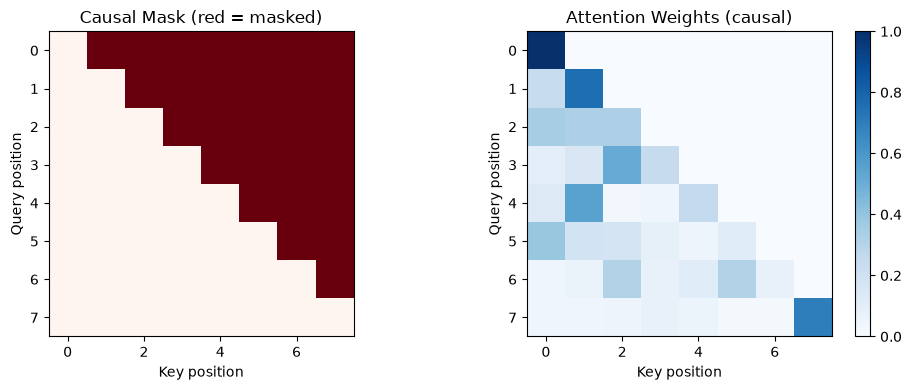

图像已保存至 results/01_causal_mask.png


In [103]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = ["DejaVu Sans", "sans-serif"]

def make_causal_mask(seq_len: int, device: torch.device) -> torch.Tensor:
    """返回上三角布尔掩码，True 表示被遮蔽（未来位置）。"""
    # torch.triu 取上三角，diagonal=1 表示主对角线上方
    return torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)

N_vis = 8
causal_mask = make_causal_mask(N_vis, device="cpu")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 掩码可视化
axes[0].imshow(causal_mask.float().numpy(), cmap="Reds", vmin=0, vmax=1)
axes[0].set_title("Causal Mask (red = masked)")
axes[0].set_xlabel("Key position")
axes[0].set_ylabel("Query position")

# 注意力权重可视化（应用因果掩码后）
torch.manual_seed(0)
Q_vis = torch.randn(1, N_vis, 16)
K_vis = torch.randn(1, N_vis, 16)
V_vis = torch.randn(1, N_vis, 16)
_, attn_vis = simple_attention(Q_vis, K_vis, V_vis, mask=causal_mask.unsqueeze(0))

im = axes[1].imshow(attn_vis[0].detach().numpy(), cmap="Blues", vmin=0)
axes[1].set_title("Attention Weights (causal)")
axes[1].set_xlabel("Key position")
axes[1].set_ylabel("Query position")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig("../results/01_causal_mask.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/01_causal_mask.png")

### 3.4 多头注意力

单头注意力只能在一个表示子空间中捕捉关系。多头注意力将 $d_{\text{model}}$ 维空间拆成 $h$ 个子空间，每个头独立学习不同的注意力模式，再拼接投影回原始维度：

$$
\text{MHA}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h) \, W^O
$$

$$
\text{head}_i = \text{Attention}(X W^Q_i,\; X W^K_i,\; X W^V_i)
$$

In [104]:
class MultiHeadAttention(nn.Module):
    """
    多头自注意力，使用 simple_attention 作为单头实现。
    输入形状：(B, N, d_model)
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.0):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须整除 num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.dropout = dropout

        # 线性投影层（将 d_model → d_model，内含所有头的参数）
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """(B, N, d_model) → (B*h, N, d_k)，将多头展开为 batch 维。"""
        B, N, _ = x.shape
        # (B, N, h, d_k) → (B, h, N, d_k) → (B*h, N, d_k)
        x = x.view(B, N, self.num_heads, self.d_k)
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(B * self.num_heads, N, self.d_k)

    def _merge_heads(self, x: torch.Tensor, B: int) -> torch.Tensor:
        """(B*h, N, d_k) → (B, N, d_model)。"""
        _, N, _ = x.shape
        x = x.view(B, self.num_heads, N, self.d_k)
        x = x.permute(0, 2, 1, 3).contiguous()
        return x.view(B, N, self.d_model)

    def forward(
        self,
        x: torch.Tensor,  # (B, N, d_model)
        mask: torch.Tensor | None = None,  # (B, N, N) 或 None
    ) -> torch.Tensor:
        B = x.size(0)

        # 投影 + 拆分多头
        Q = self._split_heads(self.W_Q(x))  # (B*h, N, d_k)
        K = self._split_heads(self.W_K(x))
        V = self._split_heads(self.W_V(x))

        # 将掩码广播到所有头
        head_mask = None
        if mask is not None:
            # mask: (B, N, N) → (B*h, N, N)
            head_mask = mask.unsqueeze(1).expand(-1, self.num_heads, -1, -1)
            head_mask = head_mask.reshape(B * self.num_heads, mask.size(-2), mask.size(-1))

        # 注意力计算
        output, _ = simple_attention(Q, K, V, mask=head_mask, dropout_p=self.dropout)

        # 合并多头 + 输出投影
        output = self._merge_heads(output, B)   # (B, N, d_model)
        output = self.W_O(output)
        return output

In [105]:
# 快速功能验证
torch.manual_seed(0)
B, N, d_model, num_heads = 4, 128, 256, 8
mha = MultiHeadAttention(d_model, num_heads).to(device)
x = torch.randn(B, N, d_model, device=device)

out = mha(x)
print(f"MHA 输入形状: {x.shape}")
print(f"MHA 输出形状: {out.shape}")
assert out.shape == (B, N, d_model)
print("MultiHeadAttention 形状正确")

# 与 PyTorch 官方 MHA 对比（相同权重）
mha_ref = nn.MultiheadAttention(
    d_model, num_heads, dropout=0.0, bias=False, batch_first=True
).to(device)

# 将权重复制到参考实现
with torch.no_grad():
    mha_ref.in_proj_weight.copy_(
        torch.cat([mha.W_Q.weight, mha.W_K.weight, mha.W_V.weight], dim=0)
    )
    mha_ref.out_proj.weight.copy_(mha.W_O.weight)

out_ref, _ = mha_ref(x, x, x, need_weights=False)
max_diff = (out - out_ref).abs().max().item()
print(f"与 nn.MultiheadAttention 最大绝对误差: {max_diff:.2e}")

MHA 输入形状: torch.Size([4, 128, 256])
MHA 输出形状: torch.Size([4, 128, 256])
MultiHeadAttention 形状正确
与 nn.MultiheadAttention 最大绝对误差: 1.04e-07


## 4 复杂度分析

设序列长度 $N$，头维度 $d_k$，批次大小 $B$，头数 $h$（$d_{\text{model}} = h \cdot d_k$）。

### 4.1 时间复杂度

| 步骤 | 操作 | FLOPs（单头，单样本） |
|------|------|----------------------|
| $QK^\top$ | $(N, d_k) \times (d_k, N)$ | $2 N^2 d_k$ |
| Softmax | 逐行归一化 | $\Theta(N^2)$ |
| $A V$ | $(N, N) \times (N, d_k)$ | $2 N^2 d_k$ |
| **合计** | | $\mathbf{\Theta(N^2 d_k)}$ |

乘以头数 $h$ 和批次大小 $B$，总 FLOPs $\approx 4BhN^2d_k = 4BN^2d_{\text{model}}$。

### 4.2 空间复杂度

朴素实现需要注意力矩阵 $S$ 和 $A$，每个形状为 $(B, h, N, N)$：

$$
\text{Memory}(A) = B \cdot h \cdot N^2 \cdot \text{sizeof(float32)}
$$

例如，$B=1, h=16, N=4096$：
$$
1 \times 16 \times 4096^2 \times 4 \text{ bytes} = 1 \text{ GB}
$$

这是标准注意力最根本的显存瓶颈，也是 FlashAttention 优化的地方。

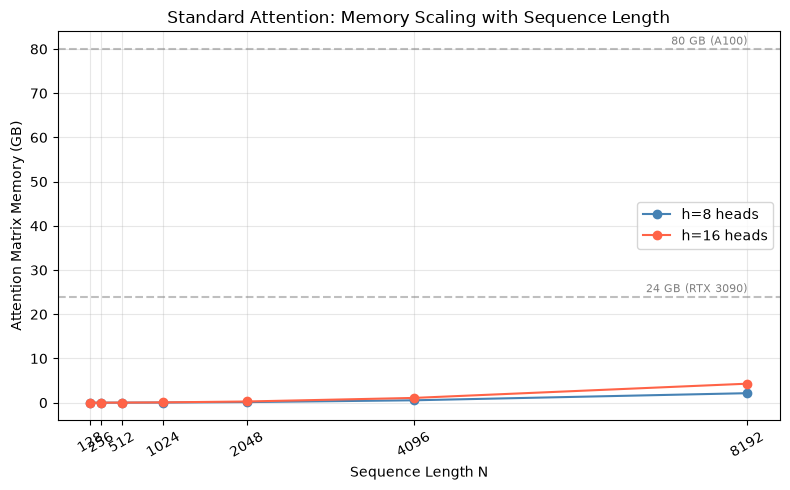

图像已保存至 results/01_memory_scaling.png


In [106]:
import numpy as np

# 可视化注意力矩阵显存随序列长度的增长
seq_lens = [128, 256, 512, 1024, 2048, 4096, 8192]
num_heads_list = [8, 16]
batch_size = 1
bytes_per_float32 = 4

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["steelblue", "tomato"]

for color, h in zip(colors, num_heads_list):
    mem_gb = [
        batch_size * h * (N ** 2) * bytes_per_float32 / 1e9
        for N in seq_lens
    ]
    ax.plot(seq_lens, mem_gb, marker="o", color=color, label=f"h={h} heads")

# 标注常见 GPU 显存线
for mem, label in [(24, "24 GB (RTX 3090)"), (80, "80 GB (A100)")]:
    ax.axhline(mem, linestyle="--", alpha=0.5, color="gray")
    ax.text(seq_lens[-1], mem + 1, label, ha="right", fontsize=8, color="gray")

ax.set_xlabel("Sequence Length N")
ax.set_ylabel("Attention Matrix Memory (GB)")
ax.set_title("Standard Attention: Memory Scaling with Sequence Length")
ax.set_xticks(seq_lens)
ax.set_xticklabels([str(n) for n in seq_lens], rotation=30)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/01_memory_scaling.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/01_memory_scaling.png")

## 5 内存访问的问题

现代 GPU 的计算吞吐量增长速度远快于 HBM 带宽，因此很多算子是受限于内存而非算力

### 标准注意力的 HBM 读写次数估算

以单头、$B=1$ 为例（字节数 = 元素数 × 4）：

| 阶段 | 读（HBM） | 写（HBM） | 说明 |
|------|-----------|-----------|------|
| 读 $Q, K$ | $2 N d_k$ | — | 计算 $QK^\top$ |
| 写 $S$ | — | $N^2$ | 存储 logits |
| 读 $S$，写 $A$ | $N^2$ | $N^2$ | Softmax |
| 读 $A, V$ | $N^2 + N d_k$ | — | 计算 $AV$ |
| 写 $O$ | — | $N d_k$ | 输出 |
| **合计** | $\approx 2N^2 + 3Nd_k$ | $\approx 2N^2 + Nd_k$ | **主项 $O(N^2)$** |

当 $N \gg d_k$ 时，HBM 访问量由 $N^2$ 项主导。FlashAttention 通过 Tiling 将中间矩阵 $S, A$ 保留在 SRAM（片上高速缓存）中，把 HBM 访问量降至 $O(N^2 d / M)$，其中 $M$ 是 SRAM 大小。

> 因此：计算本身无法省略，但可以通过减少数据搬运来显著提速。

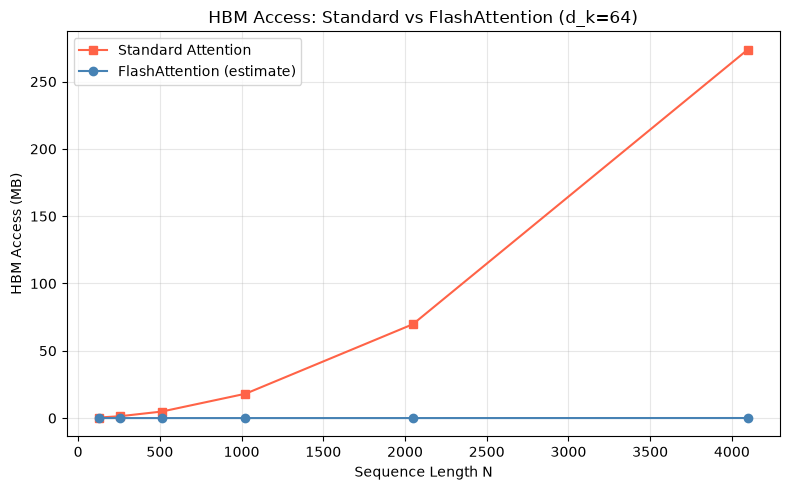

图像已保存至 results/01_hbm_access.png


In [ ]:
# HBM 访问量对比：标准注意力 vs FlashAttention（理论估算）
seq_lens_hbm = [128, 256, 512, 1024, 2048, 4096]
d_k_val = 64
M_sram = 100_000  # 假设 SRAM 可容纳约 100k 个元素（简化）

standard_hbm = [
    (4 * N**2 + 4 * N * d_k_val) * 4 / 1e6  # MB
    for N in seq_lens_hbm
]
flash_hbm = [
    (N**2 * d_k_val / M_sram) * 4 / 1e6  # MB（简化公式）
    for N in seq_lens_hbm
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(seq_lens_hbm, standard_hbm, marker="s", label="Standard Attention", color="tomato")
ax.plot(seq_lens_hbm, flash_hbm, marker="o", label="FlashAttention (estimate)", color="steelblue")
ax.set_xlabel("Sequence Length N")
ax.set_ylabel("HBM Access (MB)")
ax.set_title(f"HBM Access: Standard vs FlashAttention (d_k={d_k_val})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../results/01_hbm_access.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/01_hbm_access.png")

## 7 基准测试

使用 `torch.utils.benchmark` 计时，并记录显存峰值。

In [108]:
import torch.utils.benchmark as benchmark
import json
import os

os.makedirs("../results", exist_ok=True)

def measure_latency_and_memory(
    fn,
    *args,
    label: str = "",
    n_warmup: int = 5,
    n_repeat: int = 20,
) -> dict:
    """测量函数的延迟（ms）和显存峰值（MB）。"""
    device = args[0].device

    # 预热
    for _ in range(n_warmup):
        fn(*args)

    # 显存峰值
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
        fn(*args)
        mem_mb = torch.cuda.max_memory_allocated(device) / 1e6
    else:
        mem_mb = float("nan")

    # 延迟计时
    t = benchmark.Timer(
        stmt="fn(*args)",
        globals={"fn": fn, "args": args},
        label=label,
        num_threads=1,
    )
    result = t.timeit(n_repeat)
    return {
        "label": label,
        "latency_ms": result.mean * 1e3,
        "latency_iqr_ms": result.iqr * 1e3,
        "memory_mb": mem_mb,
    }

In [109]:
# 基准配置
BENCH_SEQ_LENS = [128, 256, 512, 1024]
if torch.cuda.is_available():
    BENCH_SEQ_LENS += [2048, 4096]  # GPU 模式下测更长序列

BENCH_D_K = 64
BENCH_BATCH = 1
BENCH_DEVICE = device

# 两种实现的包装函数
def run_naive(Q, K, V):
    return simple_attention(Q, K, V)[0]

def run_torch_sdpa(Q, K, V):
    # F.scaled_dot_product_attention 需要 (B, H, N, d)
    return F.scaled_dot_product_attention(
        Q.unsqueeze(1), K.unsqueeze(1), V.unsqueeze(1)
    ).squeeze(1)

records = []
print(f"{'N':>6}  {'Impl':>25}  {'Latency(ms)':>12}  {'Memory(MB)':>11}")
print("-" * 65)

for N in BENCH_SEQ_LENS:
    torch.manual_seed(0)
    Q = torch.randn(BENCH_BATCH, N, BENCH_D_K, device=BENCH_DEVICE)
    K = torch.randn(BENCH_BATCH, N, BENCH_D_K, device=BENCH_DEVICE)
    V = torch.randn(BENCH_BATCH, N, BENCH_D_K, device=BENCH_DEVICE)

    for impl_name, fn in [("simple_attention", run_naive), ("F.sdpa (PyTorch)", run_torch_sdpa)]:
        try:
            res = measure_latency_and_memory(fn, Q, K, V, label=f"{impl_name} N={N}")
            res["seq_len"] = N
            res["impl"] = impl_name
            records.append(res)
            print(f"{N:>6}  {impl_name:>25}  {res['latency_ms']:>11.3f}  {res['memory_mb']:>11.1f}")
        except Exception as e:
            print(f"{N:>6}  {impl_name:>25}  ERROR: {e}")

# 保存结果
with open("../results/01_benchmark_standard_attention.json", "w") as f:
    json.dump(records, f, indent=2)
print("\n基准结果已保存至 results/01_benchmark_standard_attention.json")

     N                       Impl   Latency(ms)   Memory(MB)
-----------------------------------------------------------------
   128           simple_attention        0.193         19.9
   128           F.sdpa (PyTorch)        0.397         19.8
   256           simple_attention        0.146         20.4
   256           F.sdpa (PyTorch)        0.406         19.9
   512           simple_attention        0.555         22.3
   512           F.sdpa (PyTorch)        0.985         20.2
  1024           simple_attention        0.945         29.1
  1024           F.sdpa (PyTorch)        1.276         20.7
  2048           simple_attention        7.248         55.3
  2048           F.sdpa (PyTorch)        0.477         21.7
  4096           simple_attention        1.877        158.1
  4096           F.sdpa (PyTorch)        1.405         23.8

基准结果已保存至 results/01_benchmark_standard_attention.json


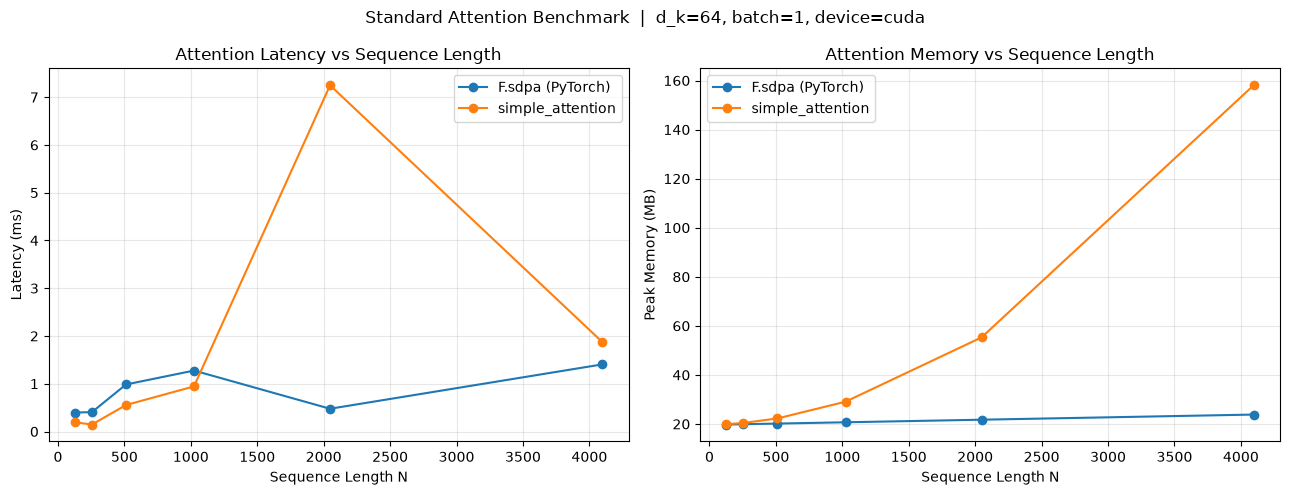

图像已保存至 results/01_benchmark_plot.png


In [112]:
# 绘制延迟对比图
import pandas as pd

df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, ylabel, title in [
    (axes[0], "latency_ms", "Latency (ms)", "Attention Latency vs Sequence Length"),
    (axes[1], "memory_mb",  "Peak Memory (MB)", "Attention Memory vs Sequence Length"),
]:
    for impl, grp in df.groupby("impl"):
        grp_sorted = grp.sort_values("seq_len")
        ax.plot(
            grp_sorted["seq_len"],
            grp_sorted[metric],
            marker="o",
            label=impl,
        )
    ax.set_xlabel("Sequence Length N")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f"Standard Attention Benchmark  |  d_k={BENCH_D_K}, batch={BENCH_BATCH}, device={BENCH_DEVICE}")
plt.tight_layout()
plt.savefig("../results/01_benchmark_plot.png", dpi=120, bbox_inches="tight")
plt.show()
print("图像已保存至 results/01_benchmark_plot.png")

- **计算与内存开销**  
  Standard Attention 需要计算 `QKᵀ`，并产生一个 `N × N` 的 attention matrix。因此，随着 sequence length `N` 增大，计算量和中间结果的存储需求都会快速增长。

- **瓶颈是内存**  
  实验结果显示，随着 sequence length 增大，Python-level `simple_attention` 的 peak memory 明显增加，而 `F.scaled_dot_product_attention` 的显存占用相对稳定。这与显式 materialize `N × N` attention matrix 所带来的内存开销相一致。

- **Latency 的实际表现**  
  本实验中的 latency 没有呈现严格单调的二次增长趋势，因此不对实际 latency 做 `N^α` 拟合。实际 GPU 性能除了受到理论计算复杂度影响，还会受到 kernel 实现、并行度和内存访问等因素影响。

- **IO 与 HBM**  
  Standard Attention 不仅需要计算 `N × N` 的中间结果，还需要在不同计算阶段读写这些数据。因此，随着 sequence length 增大，GPU memory 和 HBM traffic 都可能成为重要的性能瓶颈。本节的 HBM 分析基于简化模型进行理论估算，而不是对实际 GPU HBM traffic 的直接测量。

### 从 Standard Attention 到 FlashAttention

Standard Attention 的一个关键问题是需要显式 materialize `N × N` 的 attention matrix。

这引出了一个自然的问题：

> 能否在不显式存储完整 $N\times N$ attention matrix 的情况下，仍然精确地计算 Attention？

FlashAttention 的核心思想正是从这个问题出发：

1. **Tiling**：将 `Q`、`K`、`V` 划分为较小的 block。
2. **Online Softmax**：在分块计算过程中维护 softmax 所需的统计量。
3. **减少 HBM 访问**：避免将完整的 attention matrix 写入和读回 GPU HBM。

下一节将从 **Online Softmax** 开始，逐步推导这种分块计算方法。